<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Aula 2: Gradiente Descendente Aplicado</h1>
<h2 align="center">Resolvendo o Problema do Trocador de Calor</h2>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/NumPy-013243?style=for-the-badge&logo=numpy&logoColor=white"/>
</div>

---

## <span style="color:#1E90FF;">Contexto</span>

| Aula | O que fizemos |
|---|---|
| **Aula 0** | Encontramos a reta do trocador de calor escolhendo **dois pontos manualmente** (triângulo) |
| **Aula 1** | Construímos o algoritmo de **gradiente descendente** com NumPy |
| **Aula 2 (esta)** | Aplicamos o gradiente descendente ao mesmo problema — e comparamos os resultados |

O objetivo é mostrar que o método automático encontra uma reta **melhor** (menor MSE) do que a escolha manual de dois pontos.

---
## <span style="color:#1E90FF;">1. Carregar os Dados</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timedelta

df = pd.read_csv(Path("data/heat_exchanger.csv")).sort_values("timestamp").reset_index(drop=True)
datas = pd.to_datetime(df["timestamp"], format="%Y-%m-%d").tolist()
dia_zero = datas[0]

t_raw = np.array([(d - dia_zero).days for d in datas], dtype=np.float64)
y = df["heat_efficiency"].to_numpy(dtype=np.float64)

print(f"Amostras : {len(t_raw)}")
print(f"Período  : {datas[0].date()} → {datas[-1].date()}")

Amostras : 175
Período  : 2022-01-01 → 2022-06-30


---
## <span style="color:#1E90FF;">2. Normalização do Tempo</span>

Os valores de $t$ chegam a centenas de dias. Gradientes sobre entradas muito grandes podem ser instáveis. Normalizamos $t$ para média 0 e desvio padrão 1, rodamos o algoritmo nessa escala, e depois convertemos os parâmetros de volta para a escala original.

$$t_{\text{norm}} = \frac{t - \bar{t}}{\sigma_t}$$

Após o treino:

$$\beta_1^{\text{orig}} = \frac{\beta_1^{\text{norm}}}{\sigma_t} \qquad \beta_0^{\text{orig}} = \beta_0^{\text{norm}} - \beta_1^{\text{orig}} \cdot \bar{t}$$

In [2]:
t_mean = t_raw.mean()
t_std  = t_raw.std()
t_norm = (t_raw - t_mean) / t_std

print(f"Média de t   : {t_mean:.2f} dias")
print(f"Desvio de t  : {t_std:.2f} dias")
print(f"t normalizado: [{t_norm.min():.2f}, {t_norm.max():.2f}]")

Média de t   : 89.35 dias
Desvio de t  : 52.32 dias
t normalizado: [-1.71, 1.73]


---
## <span style="color:#1E90FF;">3. Gradiente Descendente</span>

Reutilizamos exatamente o algoritmo da Aula 1 — sem modificações.

In [3]:
def gradiente_descendente(t, y, alpha=0.01, n_iter=1000):
    n = len(y)
    beta0 = 0.0
    beta1 = 0.0
    historico = []
    for _ in range(n_iter):
        y_pred   = beta0 + beta1 * t
        residuo  = y - y_pred
        historico.append(np.mean(residuo ** 2))
        grad_b0  = (-2 / n) * np.sum(residuo)
        grad_b1  = (-2 / n) * np.sum(residuo * t)
        beta0   -= alpha * grad_b0
        beta1   -= alpha * grad_b1
    return beta0, beta1, historico


# Treinar na escala normalizada
b0_norm, b1_norm, historico = gradiente_descendente(t_norm, y, alpha=0.1, n_iter=2000)

# Converter para escala original
beta1_gd = b1_norm / t_std
beta0_gd = b0_norm - beta1_gd * t_mean

print(f"β₀ (gradiente descendente) = {beta0_gd:.4f}")
print(f"β₁ (gradiente descendente) = {beta1_gd:.6f}")
print(f"MSE final                  = {historico[-1]:.6f}")

β₀ (gradiente descendente) = 96.3428
β₁ (gradiente descendente) = -0.017919
MSE final                  = 0.002199


---
## <span style="color:#1E90FF;">4. Convergência do Algoritmo</span>

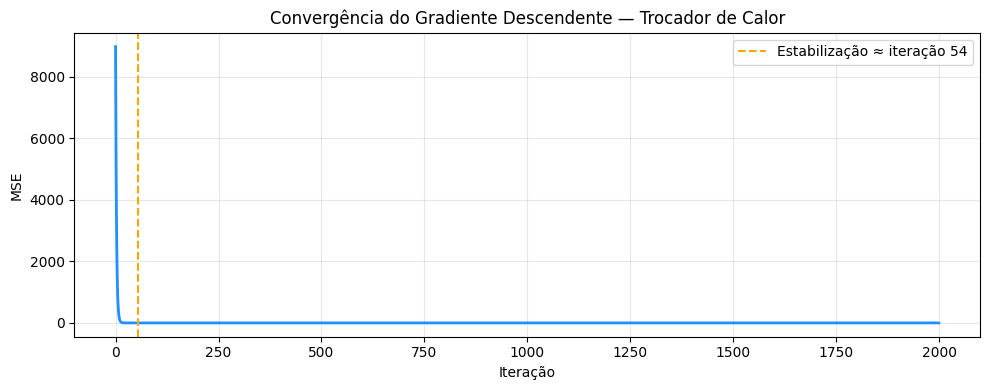

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(historico, color="#1E90FF", linewidth=2)
ax.set_xlabel("Iteração")
ax.set_ylabel("MSE")
ax.set_title("Convergência do Gradiente Descendente — Trocador de Calor")
ax.grid(True, alpha=0.3)

# Marca onde o erro estabiliza (redução < 0.01%)
for i in range(1, len(historico)):
    if abs(historico[i-1] - historico[i]) / (historico[i-1] + 1e-12) < 1e-4:
        ax.axvline(i, color="orange", linestyle="--", linewidth=1.5,
                   label=f"Estabilização ≈ iteração {i}")
        break

ax.legend()
plt.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">5. Comparação: Triângulo vs. Gradiente Descendente</span>

In [ ]:
# Parâmetros do método do triângulo (Aula 0 — dias 50 e 100)
t1, y1 = t_raw[50], y[50]
t2, y2 = t_raw[100], y[100]
beta1_tri = (y2 - y1) / (t2 - t1)
beta0_tri = y1 - beta1_tri * t1

# MSE de cada método
y_pred_tri = beta0_tri + beta1_tri * t_raw
y_pred_gd  = beta0_gd  + beta1_gd  * t_raw

mse_tri = np.mean((y - y_pred_tri) ** 2)
mse_gd  = np.mean((y - y_pred_gd)  ** 2)

reducao = (mse_tri - mse_gd) / mse_tri * 100

comparacao = pd.DataFrame(
    {
        "Triângulo (Aula 0)": [beta0_tri, beta1_tri, mse_tri],
        "Grad. Desc. (Aula 2)": [beta0_gd, beta1_gd, mse_gd],
    },
    index=["β₀", "β₁", "MSE"],
)

comparacao = comparacao.round(6)
comparacao["Redução MSE (%)"] = ["", "", f"{reducao:.2f}%"]
print(comparacao)

In [ ]:
df = comparacao.copy()
df = df.round(6)
df["Reducao_MSE (%)"] = f"{reducao:.2f}%"
print(df)

     Triângulo (Aula 0)  Grad. Desc. (Aula 2) Reducao_MSE (%)
β₀            96.302907             96.342827          45.48%
β₁            -0.017951             -0.017919          45.48%
MSE            0.004033              0.002199          45.48%


---
## <span style="color:#1E90FF;">6. Visualização Comparativa</span>

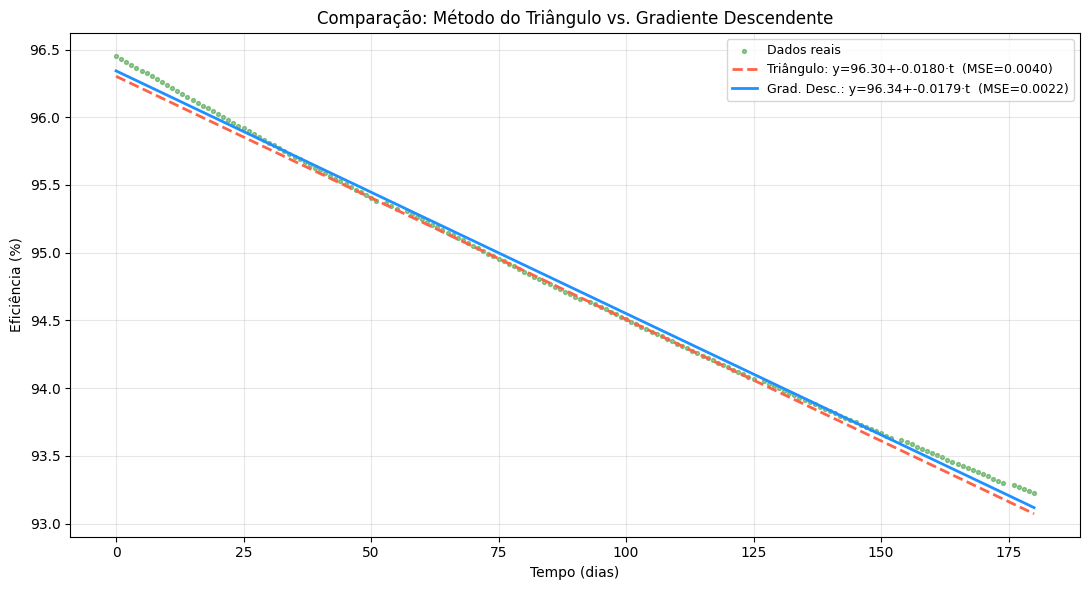

In [6]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(t_raw, y, s=8, alpha=0.4, color="green", label="Dados reais", zorder=1)
ax.plot(t_raw, y_pred_tri, color="#FF6347", linewidth=2, linestyle="--",
        label=f"Triângulo: y={beta0_tri:.2f}+{beta1_tri:.4f}·t  (MSE={mse_tri:.4f})", zorder=2)
ax.plot(t_raw, y_pred_gd,  color="#1E90FF", linewidth=2,
        label=f"Grad. Desc.: y={beta0_gd:.2f}+{beta1_gd:.4f}·t  (MSE={mse_gd:.4f})", zorder=3)

ax.set_xlabel("Tempo (dias)")
ax.set_ylabel("Eficiência (%)")
ax.set_title("Comparação: Método do Triângulo vs. Gradiente Descendente")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## <span style="color:#1E90FF;">7. Previsão: Quando Limpar o Trocador?</span>

Com os parâmetros otimizados, prevemos quando a eficiência atingirá **92%**:

$$t = \frac{y_{\text{alvo}} - \beta_0}{\beta_1}$$

In [7]:
alvo = 92.0

t_limpeza_tri = (alvo - beta0_tri) / beta1_tri
t_limpeza_gd  = (alvo - beta0_gd)  / beta1_gd

data_tri = dia_zero + timedelta(days=t_limpeza_tri)
data_gd  = dia_zero + timedelta(days=t_limpeza_gd)

print(f"Eficiência alvo       : {alvo}%")
print()
print(f"Triângulo (Aula 0)    : {t_limpeza_tri:.1f} dias → {data_tri.strftime('%Y-%m-%d')}")
print(f"Grad. Desc. (Aula 2)  : {t_limpeza_gd:.1f}  dias → {data_gd.strftime('%Y-%m-%d')}")
print()
print("→ O gradiente descendente usa TODOS os pontos para ajustar a reta,")
print("  resultando em uma previsão mais confiável.")

Eficiência alvo       : 92.0%

Triângulo (Aula 0)    : 239.7 dias → 2022-08-28
Grad. Desc. (Aula 2)  : 242.4  dias → 2022-08-31

→ O gradiente descendente usa TODOS os pontos para ajustar a reta,
  resultando em uma previsão mais confiável.


---
## <span style="color:#1E90FF;">8. Conclusão</span>

| | Triângulo | Gradiente Descendente |
|---|---|---|
| **Dados utilizados** | 2 pontos | Todos os $n$ pontos |
| **Automático** | Não — escolha manual | Sim |
| **Garante menor MSE** | Não | Sim (convergência ao ótimo) |
| **Escalável** | Não | Sim — funciona com milhões de pontos e muitas features |

### O que o Gradiente Descendente *é*, no fundo

> Imagine a superfície do MSE como um vale montanhoso. O algoritmo parte de um ponto qualquer e sempre dá um pequeno passo na direção do declive — até chegar ao fundo do vale.

Esse mesmo princípio é o **coração de todas as redes neurais modernas** — a diferença está apenas na forma da superfície (muito mais complexa) e no número de parâmetros (milhões ou bilhões). O passo de atualização, no entanto, é exatamente o mesmo.